## 1. Import Required Libraries

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [ ]:


DATA_PATH =  "/Users/alismac/Documents/Monsoon Hackthon Project/Indian Rainfall Dataset District-wise Daily Measurements.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Please place the CSV file in the same folder as this notebook "
        "or update DATA_PATH with the correct file path."
    )


data = pd.read_csv(DATA_PATH, sep=None, engine="python")

print("Dataset loaded successfully.")
print("Shape:", data.shape)

data.head()


Dataset loaded successfully.
Shape: (8790, 34)


,state,district,month,1st,2nd,3rd,4th,5th,6th,7th,...,22nd,23rd,24th,25th,26th,27th,28th,29th,30th,31st
0,Andaman & Nicobar,Nicobars,1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,Andaman & Nicobar,North And Middle Andaman,1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,Andaman & Nicobar,South Andamans,1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,Andhra Pradesh,Anantapur,1,0.379965,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.205834,0.671002,0.028994,0.0,0.0,0.0
4,Andhra Pradesh,Chittoor,1,14.144900,0.857263,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.615237,0.925098,0.507623,0.424843,0.737394,0.0,0.0,0.0


## 3. Basic Data Understanding

In [ ]:
print("Columns:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:", data.duplicated().sum())


Columns:
['state', 'district', 'month', '1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th', '10th', '11th', '12th', '13th', '14th', '15th', '16th', '17th', '18th', '19th', '20th', '21st', '22nd', '23rd', '24th', '25th', '26th', '27th', '28th', '29th', '30th', '31st']

Data Types:
state        object
district     object
month         int64
1st         float64
2nd         float64
3rd         float64
4th         float64
5th         float64
6th         float64
7th         float64
8th         float64
9th         float64
10th        float64
11th        float64
12th        float64
13th        float64
14th        float64
15th        float64
16th        float64
17th        float64
18th        float64
19th        float64
20th        float64
21st        float64
22nd        float64
23rd        float64
24th        float64
25th        float64
26th        float64
27th        float64
28th        float64
29th        float64
30th        float64
31st        float64
dtype: object

Missing Value

In [ ]:
data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
state,8790,37,Uttar Pradesh,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,8790,854,Hamirpur,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,8790.0,NaN,NaN,NaN,6.502162,3.452281,1.0,4.0,7.0,10.0,12.0
1st,8790.0,NaN,NaN,NaN,3.493094,9.82491,0.0,0.0,0.0,1.754773,218.306
2nd,8790.0,NaN,NaN,NaN,3.210606,9.245431,0.0,0.0,0.0,2.130985,321.706
3rd,8790.0,NaN,NaN,NaN,2.91556,7.179966,0.0,0.0,0.0,1.72151,83.31
4th,8790.0,NaN,NaN,NaN,3.909056,9.192568,0.0,0.0,0.000024,3.528917,183.32
5th,8790.0,NaN,NaN,NaN,4.25683,10.675278,0.0,0.0,0.0,3.31714,200.507
6th,8790.0,NaN,NaN,NaN,4.754248,12.634238,0.0,0.0,0.0,3.309595,221.427
7th,8790.0,NaN,NaN,NaN,3.174247,8.454718,0.0,0.0,0.0,1.91247,125.052


## 4. Clean Column Names

In [ ]:

data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(data.columns.tolist())


['state', 'district', 'month', '1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th', '10th', '11th', '12th', '13th', '14th', '15th', '16th', '17th', '18th', '19th', '20th', '21st', '22nd', '23rd', '24th', '25th', '26th', '27th', '28th', '29th', '30th', '31st']


## 5. Detect Daily Rainfall Columns

In [ ]:


def get_day_suffix(day):
    if 10 <= day % 100 <= 20:
        return "th"
    return {1: "st", 2: "nd", 3: "rd"}.get(day % 10, "th")


possible_day_cols = []

for day in range(1, 32):
    possible_day_cols.extend([
        str(day),
        f"{day}{get_day_suffix(day)}",
        f"day_{day}",
        f"d{day}"
    ])

day_cols = [col for col in possible_day_cols if col in data.columns]

print("Detected day columns:", day_cols)
print("Number of day columns:", len(day_cols))

if len(day_cols) == 0:
    raise ValueError(
        "No daily rainfall columns were detected. "
        "Please check the column names in the dataset."
    )


Detected day columns: ['1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th', '10th', '11th', '12th', '13th', '14th', '15th', '16th', '17th', '18th', '19th', '20th', '21st', '22nd', '23rd', '24th', '25th', '26th', '27th', '28th', '29th', '30th', '31st']
Number of day columns: 31


## 6. Handle Missing Values and Create Target Column

In [ ]:


for col in day_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data[day_cols] = data[day_cols].fillna(0)

# Monthly total rainfall is the target variable.
data["total_rainfall"] = data[day_cols].sum(axis=1)

data[["total_rainfall"]].head()


,total_rainfall
0,0.000000
1,0.000000
2,0.000000
3,2.609365
4,26.160305


## 7. Exploratory Data Analysis

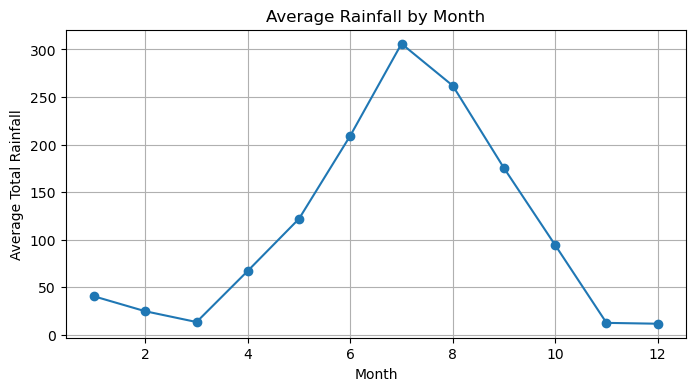

In [ ]:
monthly_rainfall = data.groupby("month")["total_rainfall"].mean()

plt.figure(figsize=(8, 4))
plt.plot(monthly_rainfall.index, monthly_rainfall.values, marker="o")
plt.title("Average Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Average Total Rainfall")
plt.grid(True)
plt.show()


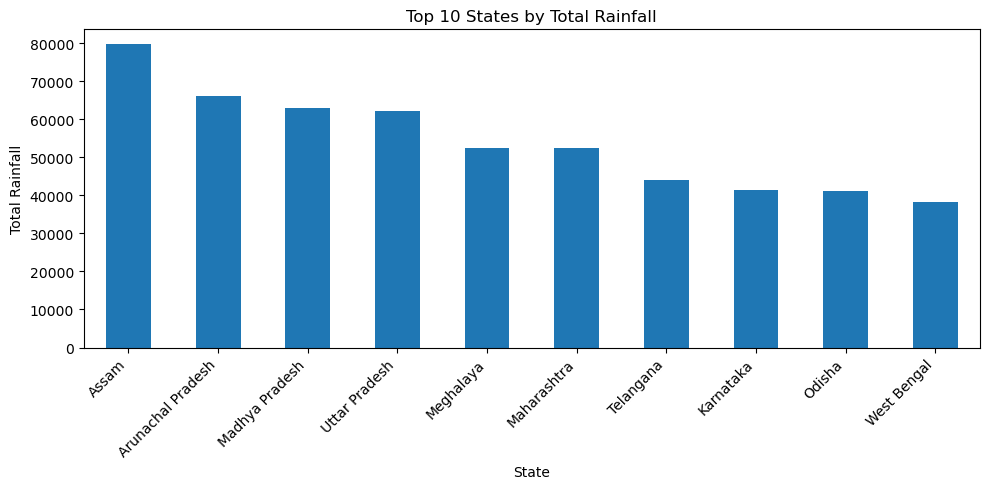

In [ ]:
state_rainfall = (
    data.groupby("state")["total_rainfall"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
state_rainfall.plot(kind="bar")
plt.title("Top 10 States by Total Rainfall")
plt.xlabel("State")
plt.ylabel("Total Rainfall")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


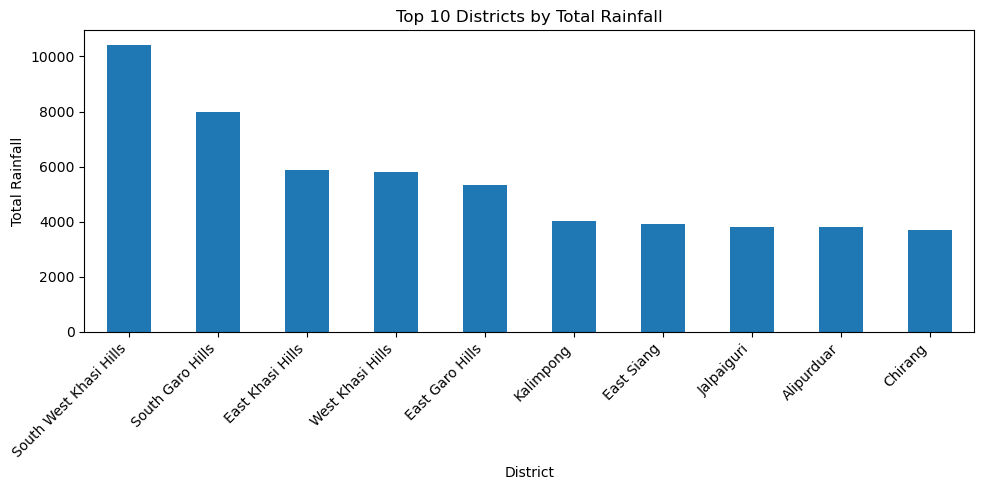

In [ ]:
district_rainfall = (
    data.groupby("district")["total_rainfall"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
district_rainfall.plot(kind="bar")
plt.title("Top 10 Districts by Total Rainfall")
plt.xlabel("District")
plt.ylabel("Total Rainfall")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Prepare Data for Machine Learning


In [ ]:
required_cols = ["state", "district", "month", "total_rainfall"]

missing_required_cols = [col for col in required_cols if col not in data.columns]

if missing_required_cols:
    raise ValueError(f"Missing required columns: {missing_required_cols}")

model_data = data[required_cols].copy()

X = model_data[["state", "district", "month"]]
y = model_data["total_rainfall"]

X.head()


,state,district,month
0,Andaman & Nicobar,Nicobars,1
1,Andaman & Nicobar,North And Middle Andaman,1
2,Andaman & Nicobar,South Andamans,1
3,Andhra Pradesh,Anantapur,1
4,Andhra Pradesh,Chittoor,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 7032
Testing rows: 1758


## 9. Build Preprocessing Pipeline

In [ ]:
categorical_features = ["state", "district"]
numeric_features = ["month"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

preprocessor
#categorical_features


,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


## 10. Train and Compare Models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": RandomForestRegressor(
        n_estimators=1,
        max_depth=8,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df


,Model,MAE,RMSE,R2 Score
2,Random Forest,43.127339,129.581721,0.648565
1,Decision Tree,60.072591,148.439524,0.538835
3,Gradient Boosting,67.569636,169.909214,0.395786
0,Linear Regression,120.220260,214.385390,0.038061


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)


Best Model: Random Forest


## 11. Actual vs Predicted Values

In [ ]:
best_predictions = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

comparison_df.head(10)


,Actual,Predicted
0,90.074580,94.905945
1,42.378330,79.179618
2,217.972385,170.867861
3,264.016345,227.323824
4,8.051079,2.058463
5,61.968460,26.945193
6,0.000000,0.000000
7,77.743290,114.553387
8,0.275392,0.300909
9,5.382205,1.078808


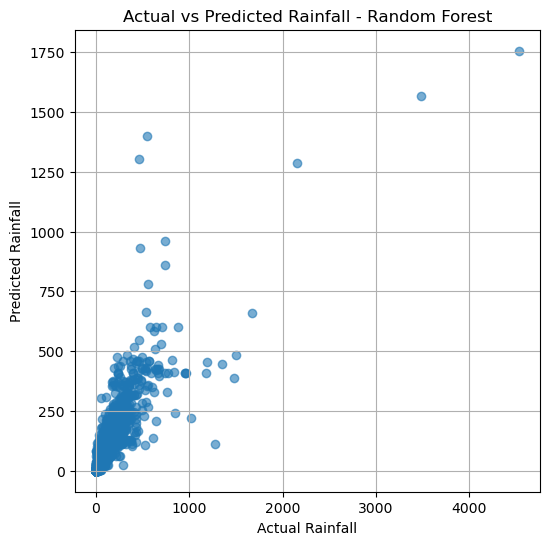

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(comparison_df["Actual"], comparison_df["Predicted"], alpha=0.6)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title(f"Actual vs Predicted Rainfall - {best_model_name}")
plt.grid(True)
plt.show()


## 12. Prediction Function

In [ ]:
def predict_rainfall(state, district, month):
    input_data = pd.DataFrame({
        "state": [state],
        "district": [district],
        "month": [month]
    })

    prediction = best_model.predict(input_data)[0]
    return prediction


# Example prediction
example_state = data["state"].iloc[0]
example_district = data["district"].iloc[0]
example_month = int(data["month"].iloc[0])

predicted_rainfall = predict_rainfall(example_state, example_district, example_month)

print("State:", example_state)
print("District:", example_district)
print("Month:", example_month)
print("Predicted Rainfall:", round(predicted_rainfall, 2))


State: Andaman & Nicobar
District: Nicobars
Month: 1
Predicted Rainfall: 7.29
